# **Lucas–Kanade**

En esta sección, implementamos el método de Lucas-Kanade. Dado que este método es costoso computacionalmente, solamente lo implementaremos para un punto en la imagen. Para ello, preprocesamos la primera imagen para encontrar un punto siguiendo los siguientes pasos:
1. Pasar la imagen a escala de grises.
2. Aplicar filtro gaussiano (visto en la práctica 3 de la asignatura).
3. Detectar bordes con Canny (https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html).
4. Buscar los contornos y escoger un punto del contorno (en este caso, escogemos el punto que menor valor de Y tenga) (https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/).


In [85]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/contours"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

Dimensiones imagen original: (720, 1280, 3)


True

Imagen original:

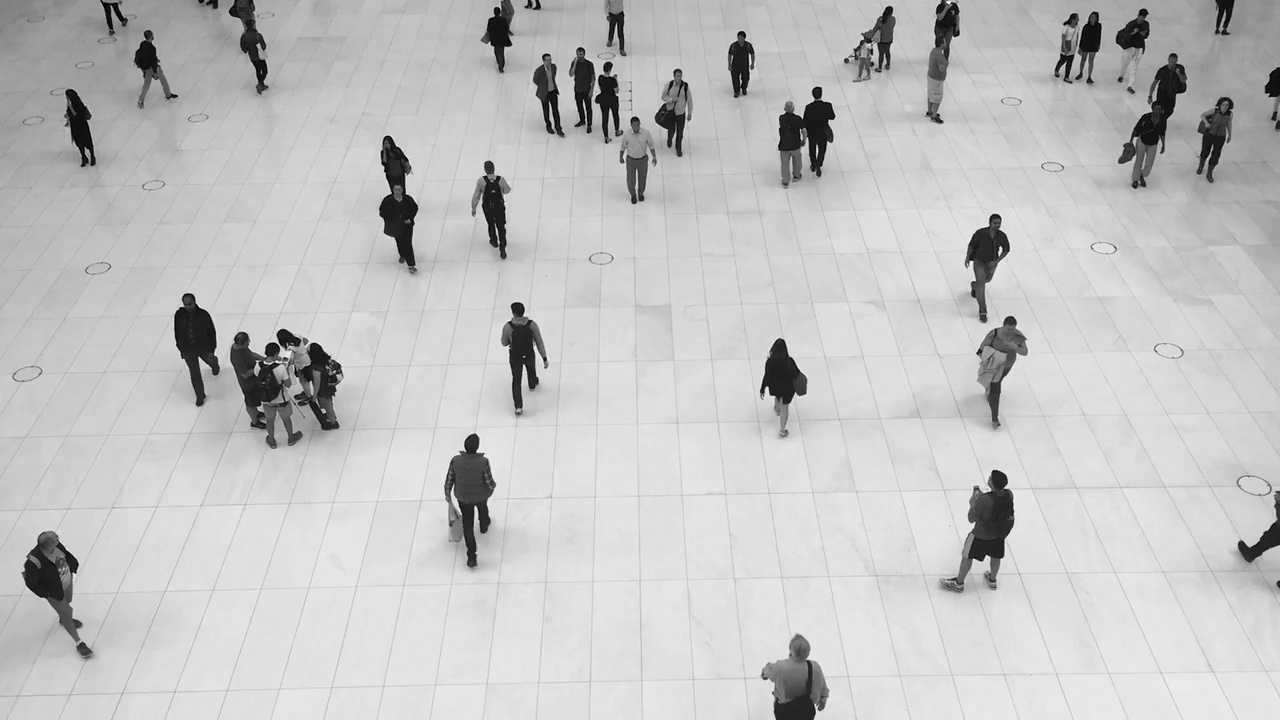

In [86]:
# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5,5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

True

Imagen con suavizado Gaussiano:

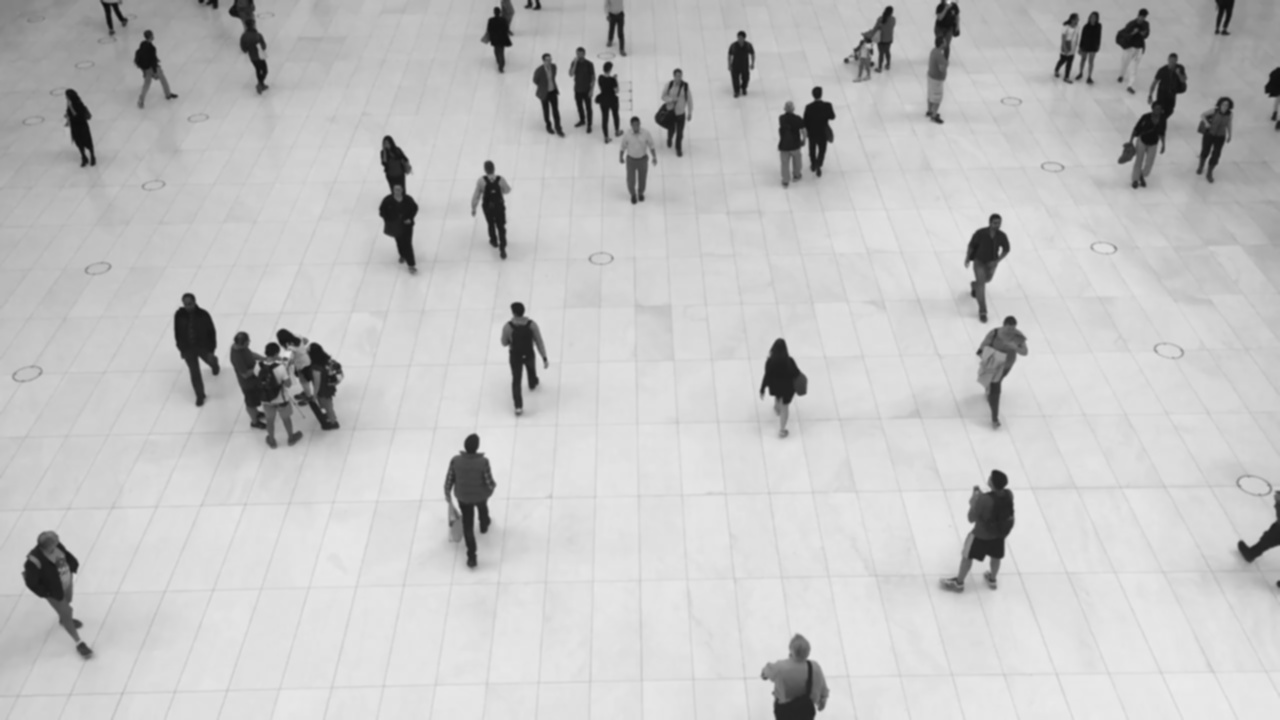

In [87]:
# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)

True

Bordes detectados con Canny:

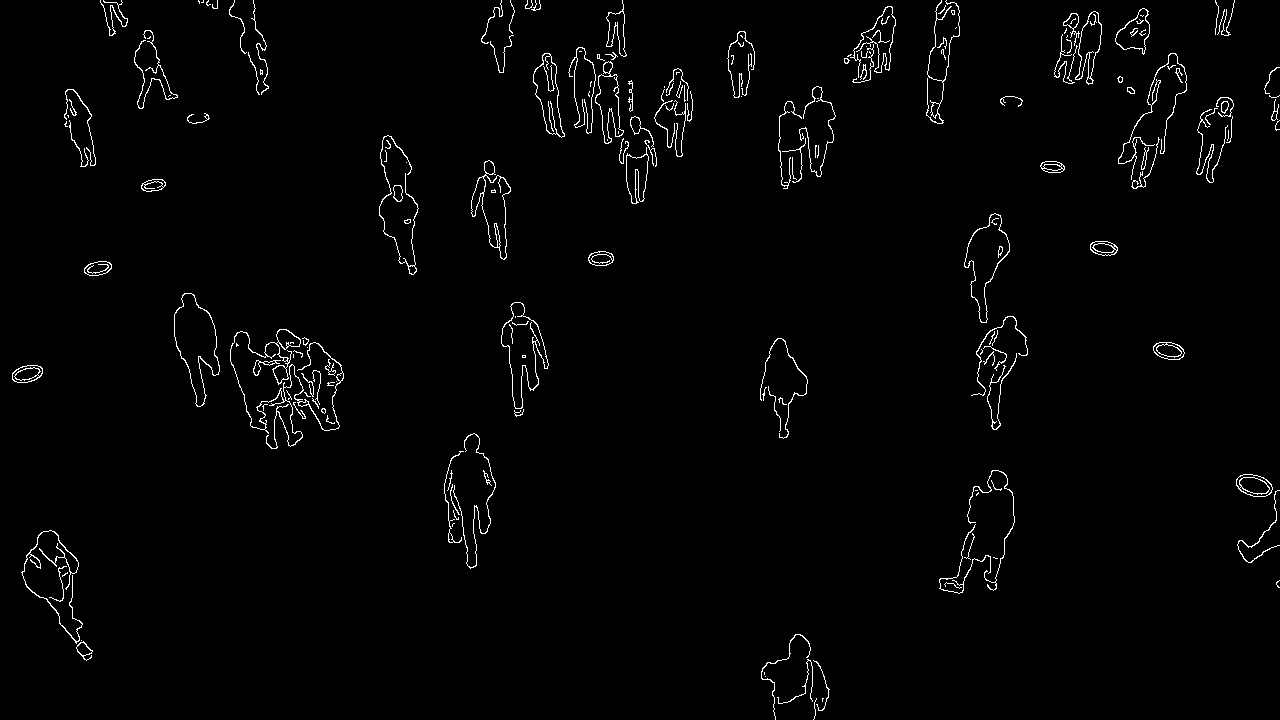

In [88]:
# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos,_) = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_img = old_gray.copy()
contornos_col = cv2.cvtColor(contornos_img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contornos_col,contornos,-1,(255,0,0), 1)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_col)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:,:,1].argmin()][0]


Los contornos encontrados son los siguientes
![Contornos obtenidos en la imagen](output/contours/contornos.jpg)

A continuación, definimos una función aplicar una máscara de tamaño 5x5. Esta máscara definirá la ventana donde calcularemos los cambios de intensidad de la imagen, para que el costo computacional no sea elevado. Esta función se la pedimos a ChatGPT.

In [89]:
def get_mask_5x5(img, point):
    x, y = point

    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask

Ahora, comenzamos con el flujo principal del método. Analizaremos 2 frames. Para ello, realizamos los siguientes pasos:
1. Obtener las intensidades de la máscara de 5x5 de la imagen 1.
2. Calcular las derivadas de intensidad con Sobel.
3. Construir la matriz de las derivadas:

$$S =
\begin{bmatrix}
dx_1 & dy_1 \\
dx_2 & dy_2 \\
\vdots & \vdots \\
dx_9 & dy_9
\end{bmatrix}$$

4. Mostrar el punto en la imagen 1.
5. Obtener las intensidades de la máscara de 5x5 de la imagen 2.
6. Obtener la matriz T:

$$T =
\begin{bmatrix}
I_t(x_1,y_1) - I_{t+\Delta t}(x_1,y_1) \\
I_t(x_2,y_2) - I_{t+\Delta t}(x_2,y_2) \\
\vdots \\
I_t(x_9,y_9) - I_{t+\Delta t}(x_9,y_9)
\end{bmatrix}$$

7. Calcular $\Delta p$:


$$\Delta p =
\begin{bmatrix}
u \\
v
\end{bmatrix}$$

$$S \, \Delta p = T$$

$$\Delta p = (S^TS)^{-1}S^TT$$

8. Calcular la posición del punto en el siguiente frame.


In [ ]:
frame_idx = 0
punto_inicial = top
old_frame_copy = old_frame.copy()

while status:
    if frame_idx ==2:
       break

	# 1. Obtener las intensidades de la máscara de 5x5 de la imagen 1.
    intensidad_1 = get_mask_5x5(old_gray, punto_inicial)
    cv2.imwrite(f"{out_dir}/mascara1_frame{frame_idx}.jpg", cv2.resize(intensidad_1, (100, 100), interpolation=cv2.INTER_NEAREST)) # cambiamos el tamaño para poder visualizarlo
  
	# 2. Calcular las derivadas de intensidad con Sobel.
    sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)
    
	# 3. Construir la matriz de las derivadas
    matrix = np.column_stack((sobelx.ravel(), sobely.ravel())) # matriz de las derivadas
  
	# 4. Mostrar el punto en la imagen 1.
    cv2.circle(old_frame_copy, punto_inicial, 2, (0, 0, 255), -1)
    cv2.imshow(f"punto inicial frame {frame_idx}", old_frame_copy)
    cv2.imwrite(f"{out_dir}/punto_inicial_frame{frame_idx}.jpg", old_frame_copy)

    #captura la imagen 2
    ret, img = frame.read()
    if not ret:
       print("No hay más frames o el frame no se pudo leer.")
       break
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
	# 5. Obtener las intensidades de la máscara de 5x5 de la imagen 2.
    intensidad_2 = get_mask_5x5(gray, punto_inicial)
    cv2.imwrite(f"{out_dir}/mascara2_frame{frame_idx}.jpg", cv2.resize(intensidad_2, (100, 100), interpolation=cv2.INTER_NEAREST)) # cambiamos el tamaño para poder visualizarlo
    
	# 6. Obtener la matriz T
    T = intensidad_1.ravel() - intensidad_2.ravel()
    
	# 7. Calcular  diferencial de p$
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    
	# 8. Calcular la posición del punto en el siguiente frame.
    top_arr = np.array(punto_inicial, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")

    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 2, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)
  
    cv2.waitKey(0)
    
    # Actualización de variables
    punto_inicial = new_point_int
    old_gray = gray
    old_frame_copy = img
    frame_idx +=1
      
frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

diff_p:
[0.29455527 0.45971541]
old point: [822. 698.]
new_point: [822.29455527 698.45971541]
diff_p:
[ 0.96252125 -2.00766959]
old point: [822. 698.]
new_point: [822.96252125 695.99233041]


Máscara 1 en el frame 0:

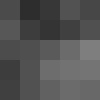

Máscara 2 en el frame 0:

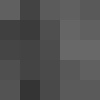

Punto inicial en el frame 0:

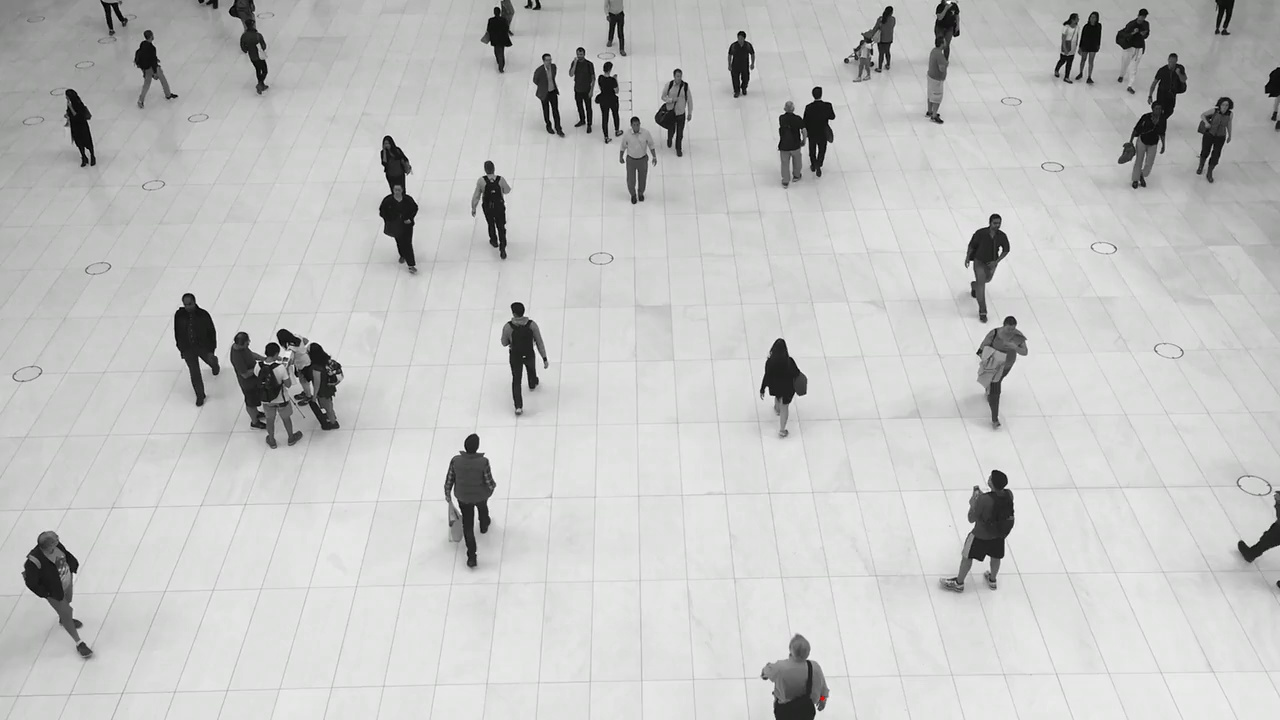

Punto final en el frame 0:

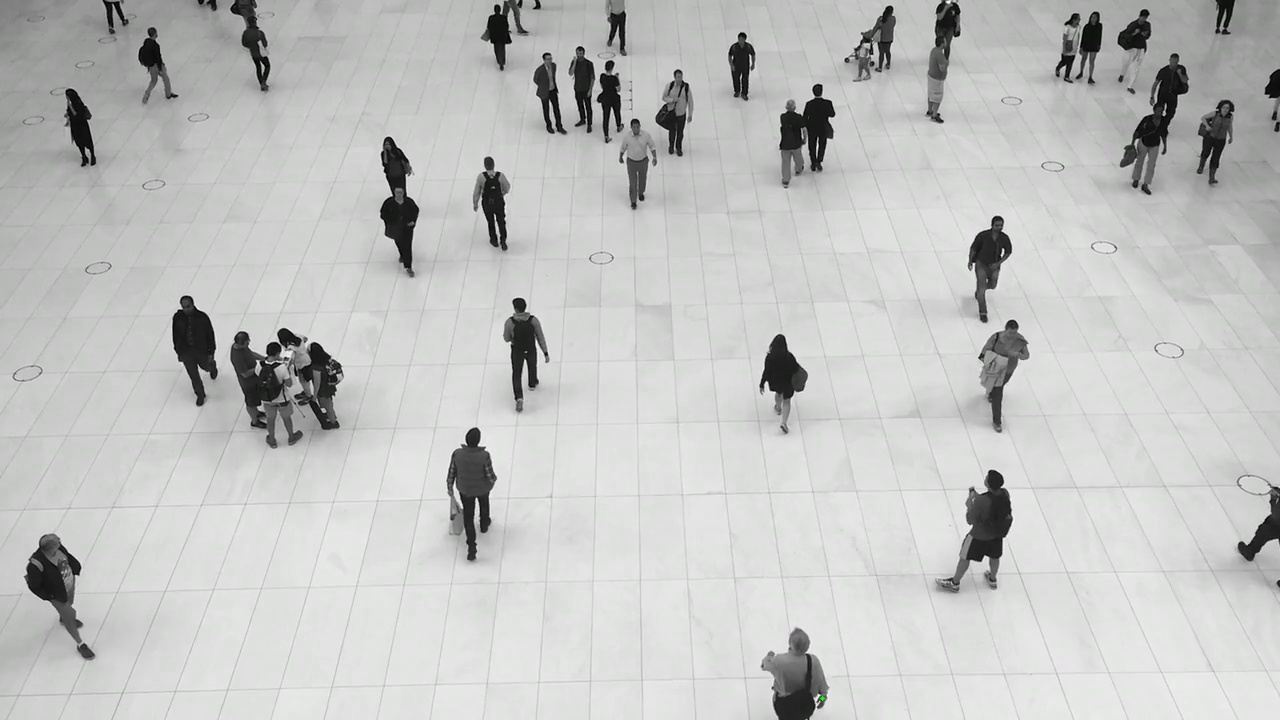
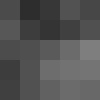
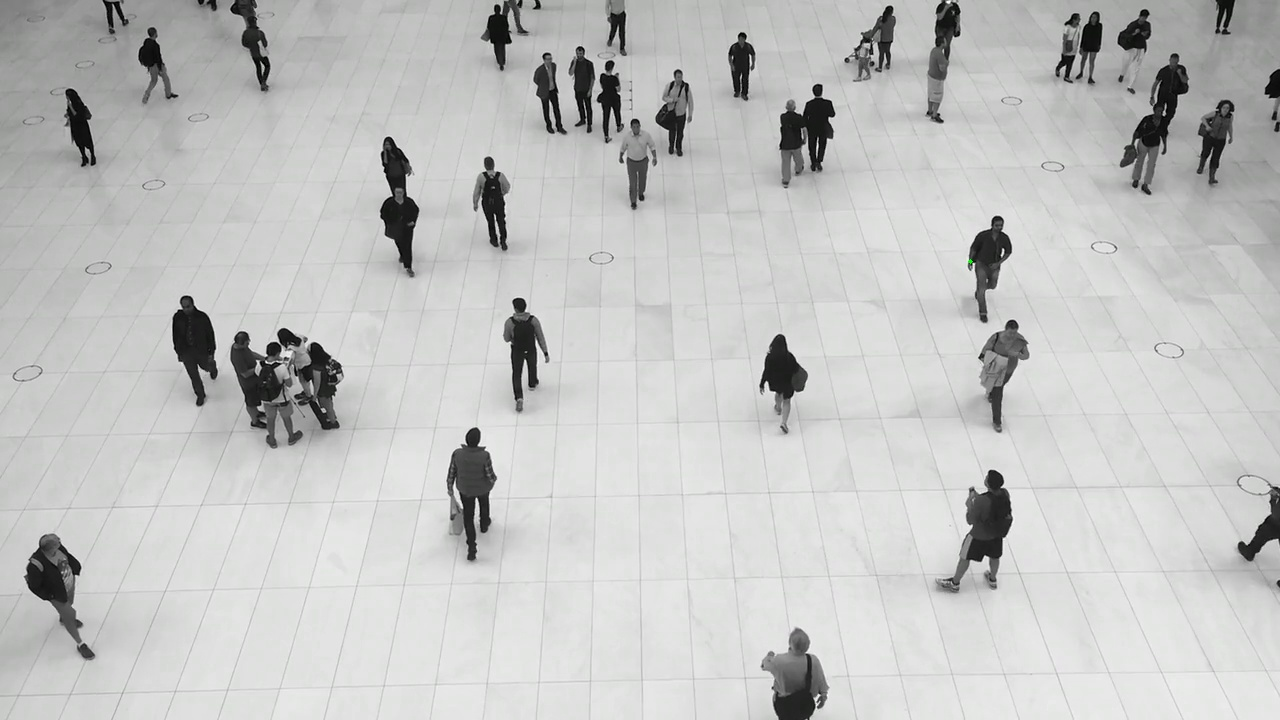

# **Lucas–Kanade (Esquinas con Harris)**
En esta sección, escogeremos el punto a seguir utilizando el Operador de Harris, para buscar esquinas. El único cambio es utilizar Harris en vez de seleccionar el punto más arriba de un contorno aleatorio.

Para aplicar Harris, utilizamos el método `cv2.goodFeaturesToTrack` explicado en https://acodigo.blogspot.com/2017/07/deteccion-de-esquinas-con-opencv.html y escogemos una esquina detectada.

In [92]:
import numpy as np
import cv2
import os

out_dir = "output/harris"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)


corners = cv2.goodFeaturesToTrack(old_gray, 40, 0.01, 10, useHarrisDetector=True)
corners = corners.astype(int)
esquinas_img = old_frame.copy()
esquinas = []
for i, corner in enumerate(corners):
    x,y = corner.ravel()
    cv2.circle(esquinas_img, (x, y), 2, (0, 0, 255), 2)
    cv2.putText(esquinas_img, f"{i}", (x+10, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1) # mostramos índices para elegir la esquina
    esquinas.append((x, y))
    
cv2.imwrite(f"{out_dir}/esquinas.jpg", esquinas_img)


Dimensiones imagen original: (720, 1280, 3)


True

Las esquinas encontradas en el primer frame  son las siguientes
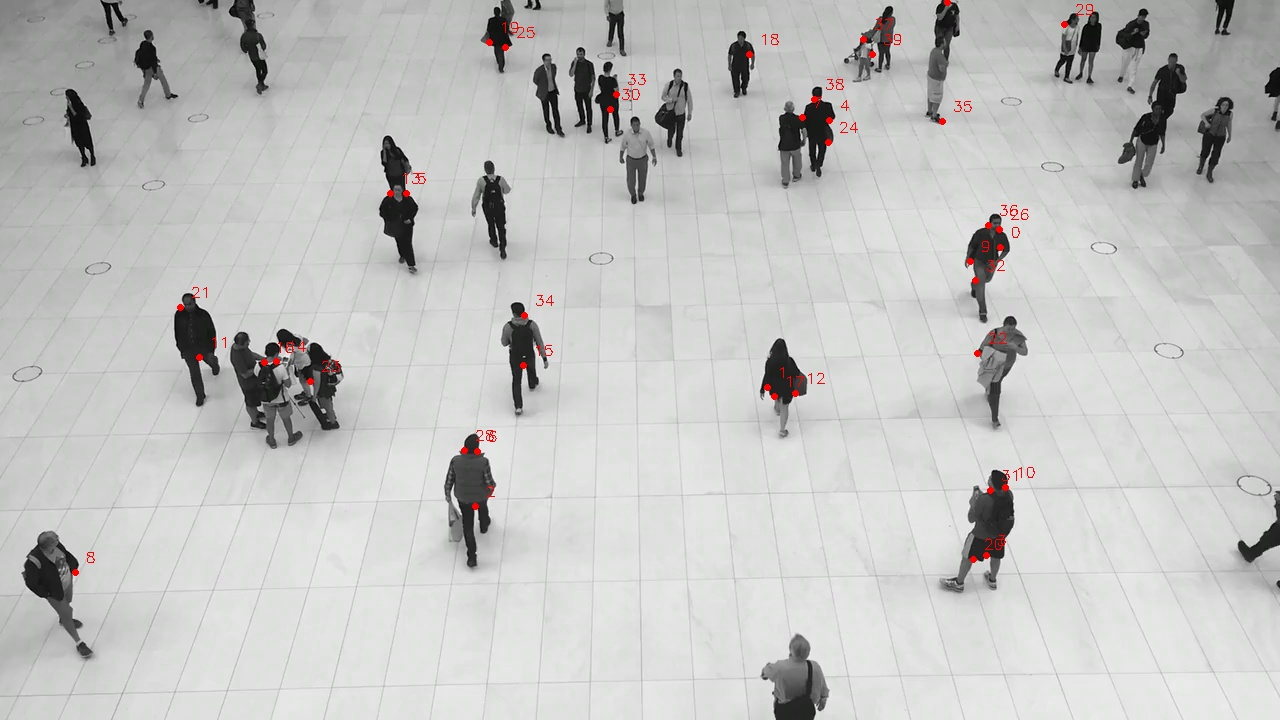

El resto del flujo sigue la misma dinámica:

In [ ]:
def get_mask_5x5(img, point):
    x, y = point

    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask


frame_idx = 0
punto_inicial = esquinas[9]
old_frame_copy = old_frame.copy()


while status:
    if frame_idx ==2:
       break

	# 1. Obtener las intensidades de la máscara de 5x5 de la imagen 1.
    intensidad_1 = get_mask_5x5(old_gray, punto_inicial)
    cv2.imwrite(f"{out_dir}/mascara1_frame{frame_idx}.jpg", cv2.resize(intensidad_1, (100, 100), interpolation=cv2.INTER_NEAREST)) # cambiamos el tamaño para poder visualizarlo
  
	# 2. Calcular las derivadas de intensidad con Sobel.
    sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)
    
	# 3. Construir la matriz de las derivadas
    matrix = np.column_stack((sobelx.ravel(), sobely.ravel())) # matriz de las derivadas
  
	# 4. Mostrar el punto en la imagen 1.
    cv2.circle(old_frame_copy, punto_inicial, 2, (0, 0, 255), -1)
    cv2.imshow(f"punto inicial frame {frame_idx}", old_frame_copy)
    cv2.imwrite(f"{out_dir}/punto_inicial_frame{frame_idx}.jpg", old_frame_copy)
  

    #captura la imagen 2
    ret, img = frame.read()
    if not ret:
       print("No hay más frames o el frame no se pudo leer.")
       break
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
	# 5. Obtener las intensidades de la máscara de 5x5 de la imagen 2.
    intensidad_2 = get_mask_5x5(gray, punto_inicial)
    cv2.imwrite(f"{out_dir}/mascara2_frame{frame_idx}.jpg", cv2.resize(intensidad_2, (100, 100), interpolation=cv2.INTER_NEAREST)) # cambiamos el tamaño para poder visualizarlo
    
	# 6. Obtener la matriz T
    T = intensidad_1.ravel() - intensidad_2.ravel()
    
	# 7. Calcular  diferencial de p$
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    
	# 8. Calcular la posición del punto en el siguiente frame.
    top_arr = np.array(punto_inicial, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")

    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 2, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)
  
    cv2.waitKey(0)
    
    # Actualización de variables
    punto_inicial = new_point_int
    old_gray = gray
    old_frame_copy = img
    frame_idx +=1
      
frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

diff_p:
[0.12943037 0.13703758]
old point: [970. 261.]
new_point: [970.12943037 261.13703758]
diff_p:
[-0.34137162 -0.09944176]
old point: [970. 261.]
new_point: [969.65862838 260.90055824]


Máscara 1 en el frame 0:

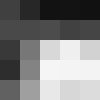

Máscara 2 en el frame 0:

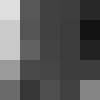

Punto inicial en el frame 0:

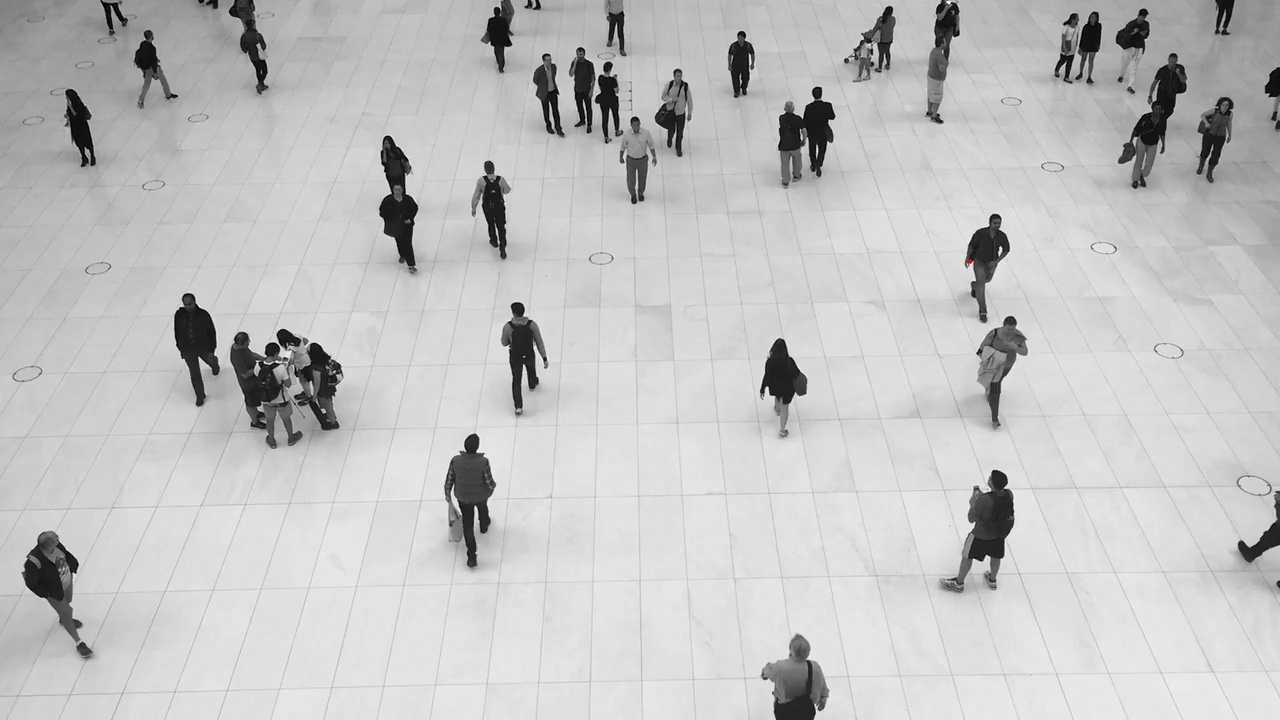

Punto final en el frame 0:

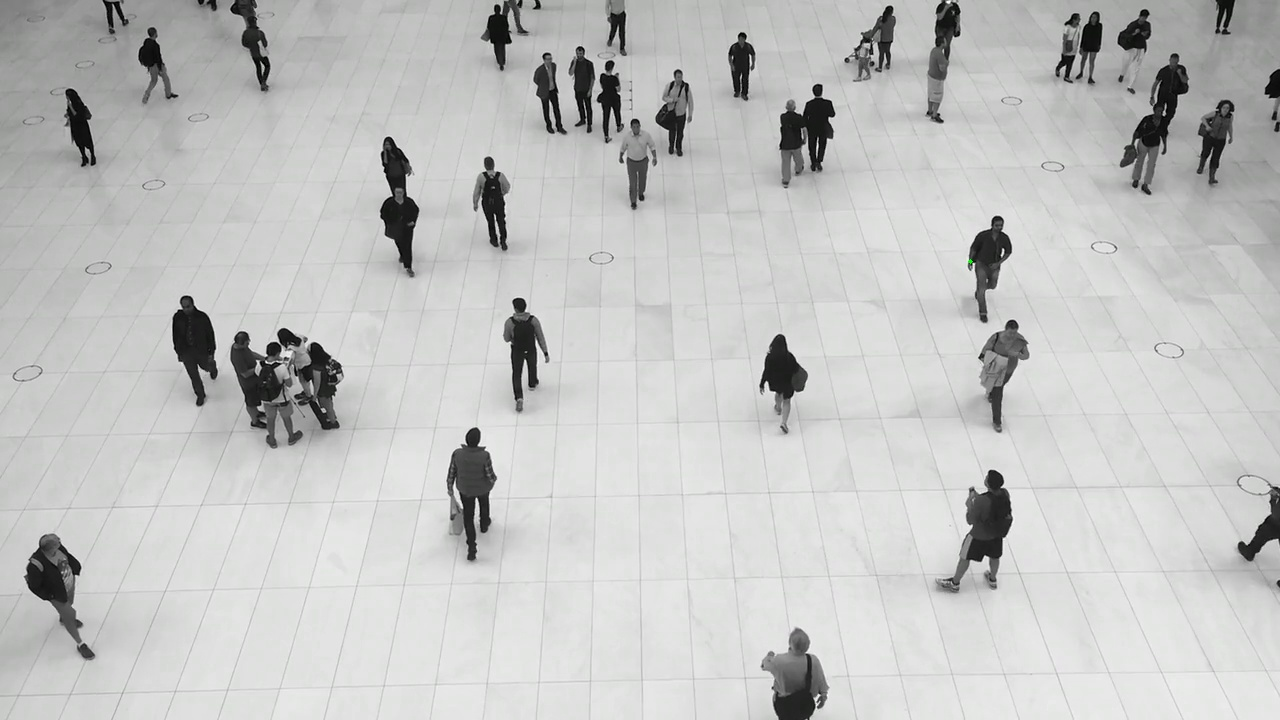

# **Versiones anteriores**

Primera versión del código. Partimos del código proporcionado, aplicamos el preprocesado de la imagen y luego el método de Lucas-Kanade siguiendo las fórmulas.

In [ ]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/1"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5,5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)
 
# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos,_) = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_img = old_gray.copy()
cv2.drawContours(contornos_img,contornos,-1,(0,0,255), 2)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_img)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:,:,1].argmin()][0]
#top = (120, 85)  # una coordenada -> TODO buscar esquina (p.e.: Harris)


# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask


intensidad_1 = get_mask_5x5(old_gray, top)

print(f"Máscara 5x5:\n{intensidad_1.shape}")

sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)

# https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html
abs_grad_x = cv2.convertScaleAbs(sobelx)
abs_grad_y = cv2.convertScaleAbs(sobely)

print(f"Magnitudes en x:\n{abs_grad_x.ravel().shape}")
print(f"Magnitudes en y:\n{abs_grad_y.ravel().shape}")
matrix = np.column_stack((abs_grad_x.ravel(), abs_grad_y.ravel())) # matrix de las derivadas
print(f"matrix:\n{matrix.shape}")
cv2.waitKey(0)
cv2.destroyAllWindows()

old_frame_copy = old_frame.copy()
cv2.circle(old_frame_copy, top, 2, (0, 0, 255), -1)
cv2.imshow("punto inicial", old_frame_copy)
cv2.imwrite(f"{out_dir}/punto_inicial_frame0.jpg", old_frame_copy)

frame_idx = 0
while status:
    if frame_idx ==2:
       break

    #captura la imagen 2
    ret, img = frame.read()
    if not ret:
       print("No hay más frames o el frame no se pudo leer.")
       break
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    intensidad_2 = get_mask_5x5(gray, top)
    
    T = intensidad_2.ravel() - intensidad_1.ravel()
    print(f"matrix.T:\n{matrix.T.shape}")
    print(f"matrix:\n{matrix.shape}")
    print(f"T:\n{T.shape}")
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    top_arr = np.array(top, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")
  
    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 3, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)
  
    cv2.waitKey(0)
  
    frame_idx +=1
      
frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

El código anterior realiza un movimiento muy brusco. ERROR

Correcciones del código anterior:
- quitar la conversión de la escala absoluta de los gradientes para que coja el signo.
- cambiar `T = intensidad_2.ravel() - intensidad_1.ravel()` a   `T = intensidad_1.ravel() - intensidad_2ravel()` siguiendo las fórmulas de las diapositivas.

In [ ]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/2"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5,5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)
 
# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos,_) = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_img = old_gray.copy()
cv2.drawContours(contornos_img,contornos,-1,(0,0,255), 2)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_img)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:,:,1].argmin()][0]
#top = (120, 85)  # una coordenada -> TODO buscar esquina (p.e.: Harris)


# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask


intensidad_1 = get_mask_5x5(old_gray, top)

print(f"Máscara 5x5:\n{intensidad_1.shape}")

sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)

print(f"sobelx:\n{sobelx.ravel().shape}")
print(f"sobely:\n{sobely.ravel().shape}")
matrix = np.column_stack((sobelx.ravel(), sobely.ravel())) # matrix de las derivadas
print(f"matrix:\n{matrix.shape}")
cv2.waitKey(0)
cv2.destroyAllWindows()

old_frame_copy = old_frame.copy()
cv2.circle(old_frame_copy, top, 2, (0, 0, 255), -1)
cv2.imshow("punto inicial", old_frame_copy)
cv2.imwrite(f"{out_dir}/punto_inicial_frame0.jpg", old_frame_copy)

frame_idx = 0
while status:
    if frame_idx ==2:
       break

    #captura la imagen 2
    ret, img = frame.read()
    if not ret:
       print("No hay más frames o el frame no se pudo leer.")
       break
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    intensidad_2 = get_mask_5x5(gray, top)
    
    T = intensidad_1.ravel() - intensidad_2.ravel()
    print(f"matrix.T:\n{matrix.T.shape}")
    print(f"matrix:\n{matrix.shape}")
    print(f"T:\n{T.shape}")
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    top_arr = np.array(top, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")
  
    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 3, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)
  
    cv2.waitKey(0)
  
    frame_idx +=1
      
frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

Ahora falta actualizar la posición del punto:

In [ ]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/3"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5,5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)
 
# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos,_) = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_img = old_gray.copy()
cv2.drawContours(contornos_img,contornos,-1,(0,0,255), 2)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_img)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:,:,1].argmin()][0]
#top = (120, 85)  # una coordenada -> TODO buscar esquina (p.e.: Harris)


# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask

frame_idx = 0
punto_inicial = top

while status:
    if frame_idx ==2:
       break

    intensidad_1 = get_mask_5x5(old_gray, punto_inicial)
  
    print(f"Máscara 5x5:\n{intensidad_1.shape}")
  
    sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)
  
    print(f"sobelx:\n{sobelx.ravel().shape}")
    print(f"sobely:\n{sobely.ravel().shape}")
    matrix = np.column_stack((sobelx.ravel(), sobely.ravel())) # matrix de las derivadas
    print(f"matrix:\n{matrix.shape}")
    cv2.waitKey(0)
    cv2.destroyAllWindows()
  
    old_frame_copy = old_frame.copy()
    cv2.circle(old_frame_copy, punto_inicial, 2, (0, 0, 255), -1)
    cv2.imshow(f"punto inicial frame {frame_idx}", old_frame_copy)
  

    #captura la imagen 2
    ret, img = frame.read()
    if not ret:
       print("No hay más frames o el frame no se pudo leer.")
       break
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    intensidad_2 = get_mask_5x5(gray, punto_inicial)
    
    T = intensidad_1.ravel() - intensidad_2.ravel()
    print(f"matrix.T:\n{matrix.T.shape}")
    print(f"matrix:\n{matrix.shape}")
    print(f"T:\n{T.shape}")
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    top_arr = np.array(punto_inicial, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")
  
    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 2, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)
  
    cv2.waitKey(0)
    
    punto_inicial = new_point_int
    frame_idx +=1
      
frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

Esquinas con Harris:

In [ ]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/4"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5,5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)
 
# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos,_) = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_img = old_gray.copy()
cv2.drawContours(contornos_img,contornos,-1,(0,0,255), 2)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_img)

cnt = contornos[0]


# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask

frame_idx = 0
old_frame_copy = old_frame.copy()
# Detectar esquinas con Harris
# https://programacionpython80889555.wordpress.com/2025/09/17/deteccion-de-esquinas-en-python-con-opencv-y-numpy/
dst = cv2.cornerHarris(canny, 2, 3, 0, 4)
dst = cv2.dilate(dst, None)
img2 = old_frame.copy()
esquinas = []
# https://acodigo.blogspot.com/2017/07/deteccion-de-esquinas-con-opencv.html
for y in range(0, img2.shape[0]):
    for x in range(0, img2.shape[1]):
        if dst.item(y, x) > 0.01 * dst.max():
            esquinas.append((x, y))
punto_inicial = esquinas[round(len(esquinas)/2)]

while status:
    if frame_idx ==2:
       break

    intensidad_1 = get_mask_5x5(old_gray, punto_inicial)
  
    print(f"Máscara 5x5:\n{intensidad_1.shape}")
  
    sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)
  
    print(f"sobelx:\n{sobelx.ravel().shape}")
    print(f"sobely:\n{sobely.ravel().shape}")
    matrix = np.column_stack((sobelx.ravel(), sobely.ravel())) # matrix de las derivadas
    print(f"matrix:\n{matrix.shape}")
    cv2.waitKey(0)
    cv2.destroyAllWindows()
  
    old_frame_copy = old_frame.copy()
    cv2.circle(old_frame_copy, punto_inicial, 2, (0, 0, 255), -1)
    cv2.imshow(f"punto inicial frame {frame_idx}", old_frame_copy)
  

    #captura la imagen 2
    ret, img = frame.read()
    if not ret:
       print("No hay más frames o el frame no se pudo leer.")
       break
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    intensidad_2 = get_mask_5x5(gray, punto_inicial)
    
    T = intensidad_1.ravel() - intensidad_2.ravel()
    print(f"matrix.T:\n{matrix.T.shape}")
    print(f"matrix:\n{matrix.shape}")
    print(f"T:\n{T.shape}")
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    top_arr = np.array(punto_inicial, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")
  
    new = img.copy()
    new2 = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 2, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)
  
    cv2.waitKey(0)
    
    punto_inicial = new_point_int
    frame_idx +=1
      
frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()